## Setup

In [46]:
import numpy as np
import matplotlib.pyplot as plt
# Set random seed for reproducibility
np.random.seed(42)

# Configure matplotlib for better display
plt.rcParams['figure.figsize'] = [8, 6]
plt.rcParams['font.size'] = 12

## Exercise 1: Implement a Perceptron Class

In [47]:
class Perceptron:
    """
    A simple Rosenblatt Perceptron implementation.
    """

    def __init__(self, n_inputs, learning_rate=0.1):
        """
        Initialise the perceptron.

        Parameters:
        -----------
        n_inputs : int
            Number of input features
        learning_rate : float
            Learning rate (alpha) for weight updates
        """
        # TODO: add code here to initialise weights to small random values (e.g., -0.5..0.5)
        ## See hint in the markdown cell above
        
        # Note: You will need to define self.weights here for the train method to work.
        # e.g., self.weights = np.random.uniform(-0.5, 0.5, n_inputs)
        
        self.bias = np.random.uniform(-0.5, 0.5)
        self.learning_rate = learning_rate
        
        ## added code here ##
        self.weights = np.random.uniform(-0.5, 0.5, n_inputs)

    def step_function(self, x):
        """
        Step activation function.

        Returns 1 if x >= 0, else 0.
        """
        # TODO: add code here to return 1 if x ≥ 0, else return 0
        ## See hint in the markdown cell above
        ## added code here ##
        return 1 if x >= 0 else 0

    def predict(self, inputs):
        """
        Compute the perceptron output for given inputs.

        Parameters:
        -----------
        inputs : array-like
            Input values (x1, x2, ...)

        Returns:
        --------
        int : 0 or 1
        """
        # TODO: add code here to compute the weighted sum
        ## See hint in the markdown cell above
        weighted_sum = np.dot(inputs, self.weights) + self.bias
        
        # Note: 'weighted_sum' needs to be calculated above before this return will work
        return self.step_function(weighted_sum)

    def train(self, X, y, epochs, verbose=True):
        """
        Train the perceptron using the perceptron learning rule.

        Parameters:
        -----------
        X : array-like, shape (n_samples, n_features)
            Training inputs
        y : array-like, shape (n_samples,)
            Target outputs (0 or 1)
        epochs : int
            Number of training epochs
        verbose : bool
            If True, print weights after each epoch

        Returns:
        --------
        list : History of (weights, bias) tuples for each epoch
        """
        history = []

        # Store initial weights
        history.append((self.weights.copy(), self.bias))

        for epoch in range(epochs):
            total_error = 0

            for i in range(len(X)):
                # Get prediction
                prediction = self.predict(X[i])

                # Calculate error
                error = y[i] - prediction
                total_error += abs(error)

                # Update weights and bias
                self.weights += self.learning_rate * error * X[i]
                self.bias += self.learning_rate * error

            # Store weights after this epoch
            # TODO: add code here to store weights after each epoch in a list
            ## See hint in the markdown cell above
            history.append((self.weights.copy(), self.bias))

            if verbose:
                print(f"Epoch {epoch + 1}: weights = {self.weights}, bias = {self.bias:.4f}, errors = {total_error}")

            # Early stopping if no errors
            if total_error == 0:
                if verbose:
                    print(f"Converged after {epoch + 1} epochs!")
                break

        return history

## Exercise 2: Train the Perceptron for Logical AND
### Task 2.1: Define the Training Data

In [48]:
# Define training data for AND
X_and = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]])

y_and = np.array([0, 0, 0, 1])

print("AND Training Data:")
print("X:")
print(X_and)
print("y:", y_and)

AND Training Data:
X:
[[0 0]
 [0 1]
 [1 0]
 [1 1]]
y: [0 0 0 1]


## Task 2.2: Train and Test Perceptron


In [49]:
# Create Perceptron
perceptron_and = Perceptron(n_inputs=2, learning_rate=1.0)

print("Inital weights:", perceptron_and.weights)
print("Inital bias:", perceptron_and.bias)
print("\nTraining...\n")

# Train (store the histroy for later visualisation)
history_and = perceptron_and.train(X_and, y_and, epochs=10)

# test on all inputs
print("\nTesting AND perceptron:")
print("-" * 40)
all_correct = True

for i in range(len(X_and)):
    prediction = perceptron_and.predict(X_and[i])
    correct = "✓" if prediction == y_and[i] else "✕"
    if prediction != y_and[i]:
        all_correct = False
    print(f"Input: {X_and[i]} -> Predicted: {prediction}, Expected: {y_and[i]} {correct}")

print("-" * 40)
print(f"All predictions correct: {all_correct}")

Inital weights: [0.45071431 0.23199394]
Inital bias: -0.1254598811526375

Training...

Epoch 1: weights = [1.45071431 0.23199394], bias = -0.1255, errors = 2
Epoch 2: weights = [1.45071431 0.23199394], bias = -1.1255, errors = 3
Epoch 3: weights = [1.45071431 1.23199394], bias = -1.1255, errors = 2
Epoch 4: weights = [2.45071431 1.23199394], bias = -1.1255, errors = 2
Epoch 5: weights = [2.45071431 1.23199394], bias = -2.1255, errors = 3
Epoch 6: weights = [2.45071431 2.23199394], bias = -2.1255, errors = 2
Epoch 7: weights = [2.45071431 1.23199394], bias = -3.1255, errors = 1
Epoch 8: weights = [2.45071431 1.23199394], bias = -3.1255, errors = 0
Converged after 8 epochs!

Testing AND perceptron:
----------------------------------------
Input: [0 0] -> Predicted: 0, Expected: 0 ✓
Input: [0 1] -> Predicted: 0, Expected: 0 ✓
Input: [1 0] -> Predicted: 0, Expected: 0 ✓
Input: [1 1] -> Predicted: 1, Expected: 1 ✓
----------------------------------------
All predictions correct: True


### Task 2.3: Visualise the Decision Boundary

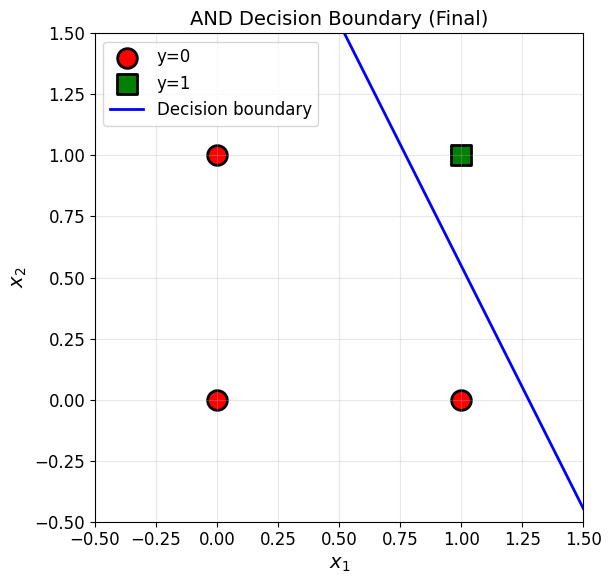

In [50]:
# Plotting function
def plot_decision_boundary(X, y, weights, bias, title="Decision Boundary", ax=None):
    """
    Plot data points and decision boundary.
    
    Parameters:
    -----------
    X : array-like, shape (n_samples, 2)
        Input data points
    y : array-like, shape (n_samples,)
        Labels (0 or 1)    
    weights : array-like, shape (2,)        
        Perceptron weights [w1, w2]
    bias : float
        Perceptron bias
    title : str
        Plot title
    ax : matplotlib axis (optional)
        Axis to plot on. If None, creates new figure.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    # Plot points
    for i in range(len(X)):
        if y[i] == 0:
            ax.scatter(X[i, 0], X[i, 1], c='red', marker='o', s=200, 
                      edgecolors='black', linewidths=2, label='y=0' if i == 0 else '')
        else:
            ax.scatter(X[i, 0], X[i, 1], c='green', marker='s', s=200, 
                      edgecolors='black', linewidths=2, label='y=1' if i == 3 else '')
    
    # Plot decision boundary
    # Line: w1*x1 + w2*x2 + b = 0
    # => x2 = -(w1/w2)*x1 - b/w2
    
    x1_range = np.linspace(-0.5, 1.5, 100)
    
    if abs(weights[1]) > 1e-10:  # Avoid division by zero
        x2_boundary = -(weights[0] / weights[1]) * x1_range - (bias / weights[1])
        ax.plot(x1_range, x2_boundary, 'b-', linewidth=2, label='Decision boundary')
    else:
        # Vertical line case
        if abs(weights[0]) > 1e-10:
            x1_boundary = -bias / weights[0]
            ax.axvline(x=x1_boundary, color='b', linewidth=2, label='Decision boundary')
    
    # Formatting
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel('$x_1$', fontsize=14)
    ax.set_ylabel('$x_2$', fontsize=14)
    ax.set_title(title, fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left')
    ax.set_aspect('equal')
    
    return ax

# Test the plotting function with the trained AND perceptron
plot_decision_boundary(X_and, y_and, perceptron_and.weights, perceptron_and.bias, 
                       "AND Decision Boundary (Final)")
plt.tight_layout()
plt.show()

### Task 2.4: Animate the Learning Process

AND - Decision Boundary Evolution:


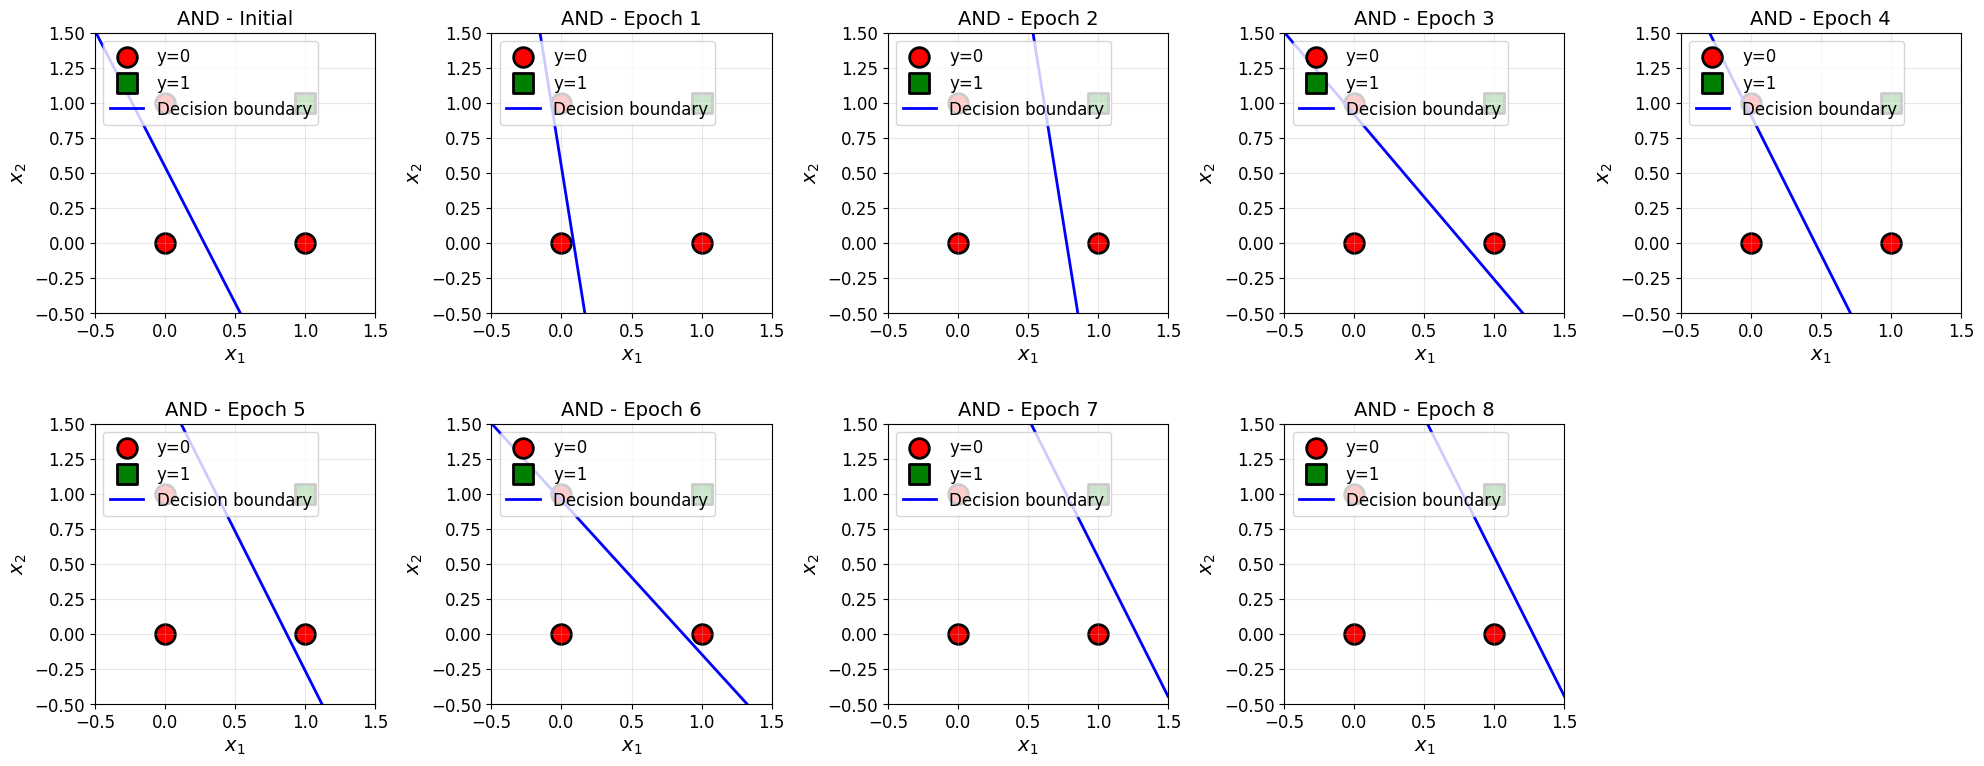

In [51]:
# Visualise decision boundary evolution across epochs
def plot_training_evolution(X, y, history, title_prefix=""):
    """
    Plot decision boundary evolution across training epochs.
    """
    n_epochs = len(history)
    
    # Determine grid size
    n_cols = min(5, n_epochs)
    n_rows = (n_epochs + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    
    # Handle single row case
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    for idx, (weights, bias) in enumerate(history):
        row = idx // n_cols
        col = idx % n_cols
        ax = axes[row, col]
        
        epoch_label = "Initial" if idx == 0 else f"Epoch {idx}"
        plot_decision_boundary(X, y, weights, bias, 
                              f"{title_prefix}{epoch_label}", ax=ax)
    
    # Hide empty subplots
    for idx in range(n_epochs, n_rows * n_cols):
        row = idx // n_cols
        col = idx % n_cols
        axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()
    
# Plot AND training evolution
print("AND - Decision Boundary Evolution:")
plot_training_evolution(X_and, y_and, history_and, "AND - ")

### Task 2.5: Display Weight Updates Table

In [52]:
import pandas as pd
def create_weight_table(history):
    """
    Create a pandas DataFrame showing weights at each epoch.
    """
    data = {
        'Epoch': [],
        'w₁': [],
        'w₂': [],
        'bias': []
    }
    
    for epoch, (weights, bias) in enumerate(history):
        data['Epoch'].append('Initial' if epoch == 0 else epoch)
        data['w₁'].append(f"{weights[0]:.4f}")
        data['w₂'].append(f"{weights[1]:.4f}")
        data['bias'].append(f"{bias:.4f}")
    
    return pd.DataFrame(data)

print("AND - Weight History Table:")
df_and = create_weight_table(history_and)
display(df_and)

AND - Weight History Table:


,Epoch,w₁,w₂,bias
0,Initial,0.4507,0.2320,-0.1255
1,1,1.4507,0.2320,-0.1255
2,2,1.4507,0.2320,-1.1255
3,3,1.4507,1.2320,-1.1255
4,4,2.4507,1.2320,-1.1255
5,5,2.4507,1.2320,-2.1255
6,6,2.4507,2.2320,-2.1255
7,7,2.4507,1.2320,-3.1255
8,8,2.4507,1.2320,-3.1255


## Exercise 3: Train the Perceptron
## Task 3.1: Define Data, Train, and Visualise

OR Training Data:
X:
[[0 0]
 [0 1]
 [1 0]
 [1 1]]
y: [0 1 1 1]
Inital weights: [-0.34398136 -0.34400548]
Inital bias: 0.0986584841970366

Training...

Epoch 1: weights = [0.65601864 0.65599452], bias = 1.0987, errors = 3
Epoch 2: weights = [0.65601864 0.65599452], bias = 0.0987, errors = 1
Epoch 3: weights = [0.65601864 1.65599452], bias = 0.0987, errors = 2
Epoch 4: weights = [1.65601864 1.65599452], bias = 0.0987, errors = 2
Epoch 5: weights = [1.65601864 1.65599452], bias = -0.9013, errors = 1
Epoch 6: weights = [1.65601864 1.65599452], bias = -0.9013, errors = 0
Converged after 6 epochs!

Testing OR perceptron:
----------------------------------------
Input: [0 0] -> Predicted: 0, Expected: 0 ✓
Input: [0 1] -> Predicted: 1, Expected: 1 ✓
Input: [1 0] -> Predicted: 1, Expected: 1 ✓
Input: [1 1] -> Predicted: 1, Expected: 1 ✓
----------------------------------------
All predictions correct: True


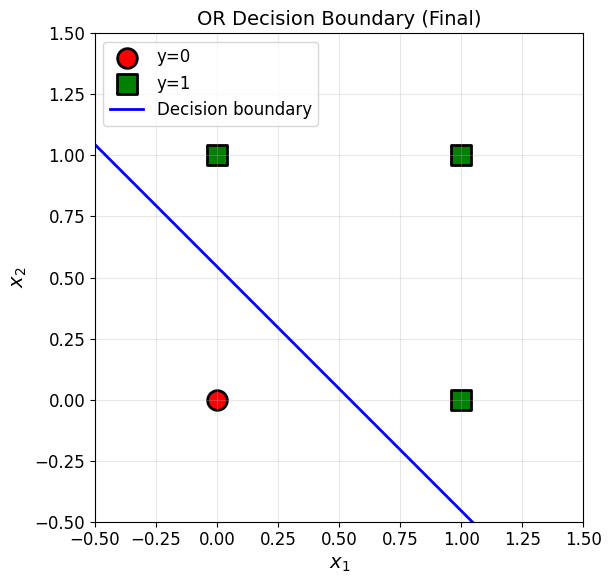

OR - Weight History Table:


,Epoch,w₁,w₂,bias
0,Initial,-0.3440,-0.3440,0.0987
1,1,0.6560,0.6560,1.0987
2,2,0.6560,0.6560,0.0987
3,3,0.6560,1.6560,0.0987
4,4,1.6560,1.6560,0.0987
5,5,1.6560,1.6560,-0.9013
6,6,1.6560,1.6560,-0.9013


In [53]:
# --- 3.1.1. Define the training data for the OR operation: ---
X_or = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]])

y_or = np.array([0, 1, 1, 1])

print("OR Training Data:")
print("X:")
print(X_or)
print("y:", y_or)

# --- 3.1.2 Train a new perceptron for the OR operation: ---
# Create Perceptron
perceptron_or = Perceptron(n_inputs=2, learning_rate=1.0)

print("Inital weights:", perceptron_or.weights)
print("Inital bias:", perceptron_or.bias)
print("\nTraining...\n")

# Train (store the histroy for later visualisation)
history_or = perceptron_or.train(X_or, y_or, epochs=10)

# test on all inputs
print("\nTesting OR perceptron:")
print("-" * 40)
all_correct = True

for i in range(len(X_or)):
    prediction = perceptron_or.predict(X_or[i])
    correct = "✓" if prediction == y_or[i] else "✕"
    if prediction != y_or[i]:
        all_correct = False
    print(f"Input: {X_or[i]} -> Predicted: {prediction}, Expected: {y_or[i]} {correct}")

print("-" * 40)
print(f"All predictions correct: {all_correct}")

# --- 3.1.3 Test and verify the OR operation: ---
# TODO: add code here to plot the decision boundary
## Hint: reuse the "plot_decision_boundary" method you've already defined in Task 2.3
plot_decision_boundary(X_or, y_or, perceptron_or.weights, perceptron_or.bias, 
                       "OR Decision Boundary (Final)")
plt.tight_layout()
plt.show()

# TODO: add code here to draw the weight history table
## Hint: reuse the "create_weight_table" method you've already defined in Task 2.5
print("OR - Weight History Table:")
df_or = create_weight_table(history_or)
display(df_or)

## Task 3.2: Compare AND and OR Decision Coundaries
**Discussion Questions:**
- How do the slopes of the decision coundaries differ?
- What is the geometric interpretation of the difference?
- Why are both problems solvable by a single perceptron?

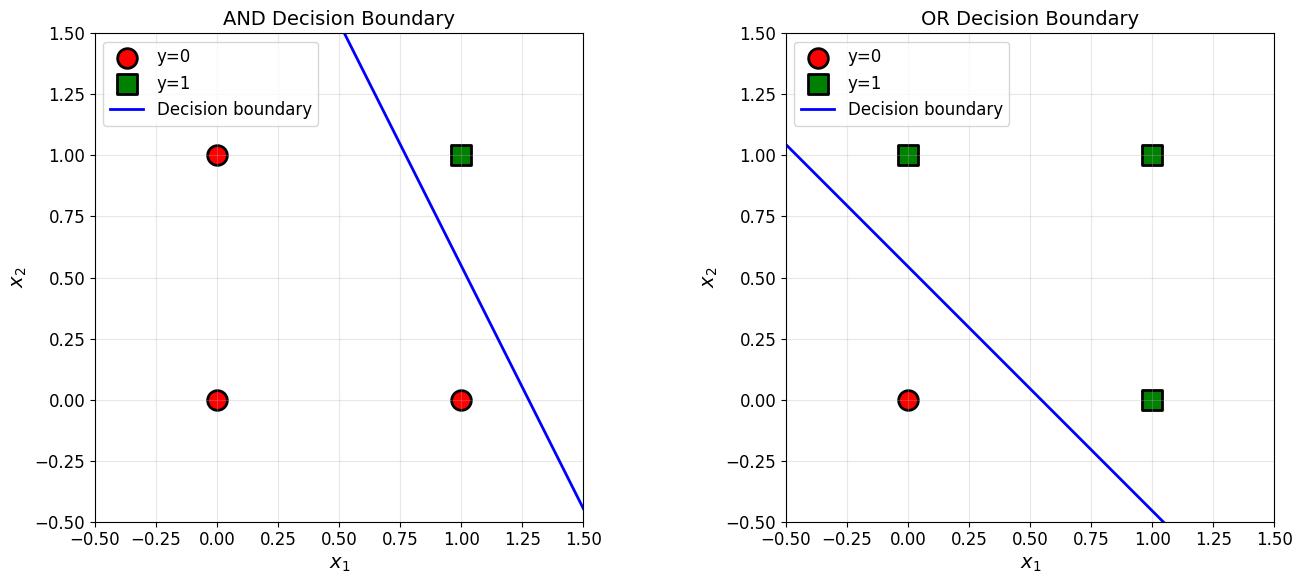

Discussion:
------------------------------------------------------------
AND: The decision boundary separates (1,1) from the other three points.
     The line passes 'above' most points, classifying only the top-right as 1.

OR:  The decision boundary separates (0,0) from the other three points.
     The line passes 'below' most points, classifying only the origin as 0.

Both are solvable because in each case, the two classes can be separated
by a single straight line - they are LINEARLY SEPARABLE.


In [54]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

plot_decision_boundary(X_and, y_and, perceptron_and.weights, perceptron_and.bias, 
                       "AND Decision Boundary", ax=ax1)
plot_decision_boundary(X_or, y_or, perceptron_or.weights, perceptron_or.bias, 
                       "OR Decision Boundary", ax=ax2)
plt.tight_layout()
plt.show()

# Discussion
print("Discussion:")
print("-" * 60)
print("AND: The decision boundary separates (1,1) from the other three points.")
print("     The line passes 'above' most points, classifying only the top-right as 1.")
print()
print("OR:  The decision boundary separates (0,0) from the other three points.")
print("     The line passes 'below' most points, classifying only the origin as 0.")
print()
print("Both are solvable because in each case, the two classes can be separated")
print("by a single straight line - they are LINEARLY SEPARABLE.")